# Demo: Contingency Management Drone Model

Explanation and demo

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```

In [74]:
from fmdtools_examples.airspacelib.contingency_management.model_aircraft import ContingencyAircraftArchitecture, pos
from fmdtools_examples.airspacelib.contingency_management.model_aircraft import plot_flightpath, plot_flightpath_from
from fmdtools_examples.airspacelib.contingency_management.model_environment import properties, collections
from fmdtools.analyze.common import consolidate_legend
from fmdtools.define.architecture.function import FunctionArchitectureGraph
from fmdtools.sim import propagate
from fmdtools.analyze.phases import from_hist
from fmdtools.sim.sample import FaultDomain, FaultSample
from fmdtools.analyze.tabulate import FMEA, result_summary_fmea, Comparison

from IPython.display import HTML

The hurricane aircraft architecture follows our desired FRDL architecture:

In [75]:
ha = ContingencyAircraftArchitecture()
ha

contingencyaircraftarchitecture ContingencyAircraftArchitecture
- t=Time(time=-0.1, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- force=Force(s=(weight=1.0, contact_support=0.0, lift_support=1.0))
- electricity=Electricity(s=(charge=100.0, voltage_high=1.0, current_high=1.0, power_high=False, voltage_low=1.0, cur...
- trajectories=Trajectories(s=(x=10.0, goal_x=10.0, dx=0.0, y=10.0, goal_y=10.0, dy=0.0, z=0.0, goal_z=0.0, dz=0.0))
- environment=ContingencyEnvironment(c=(), ga=())
FXNS:
- conditions=ContingencyConditions()
- control_flight=ContingencyControlFlight(s=(flightplan=((10.0, 10.0), (50.0, 10.0), (50.0, 100.0), (100.0, 100.0)), ...
- aviate=ContingencyAviate(m=(mode='idle', faults=set(), sub_faults=False))
- store_and_supply_ee=StoreAndSupplyElectricity(m=(mode='charged', faults=set(), sub_faults=False))
- perceive_environment=PerceiveEnvironment(m=(mode='nominal', faults=set(), sub_faults=False))
- hold_payload=HoldPayload(m=(mode='nominal', fau

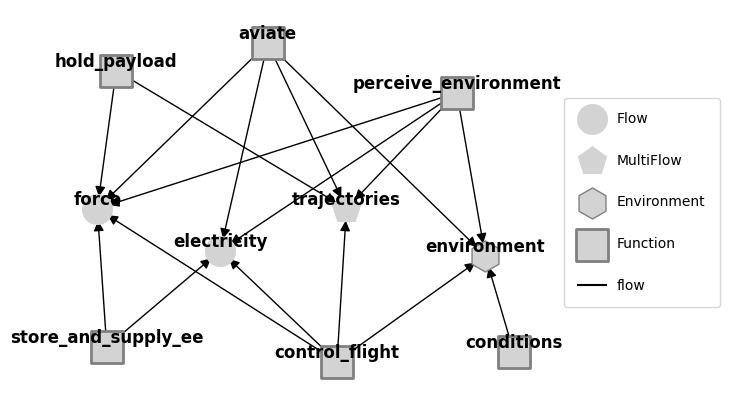

In [76]:
fg = FunctionArchitectureGraph(ha)
fg.set_edge_labels(title='')
fg.set_pos(**pos)
fig, ax = fg.draw(figsize=(6.5,5))
fig.savefig("outputs_demo_contingency/hac_arch.pdf",  bbox_inches='tight')
fig.savefig("outputs_demo_contingency/hac_arch.svg",  bbox_inches='tight')

In [77]:
# %matplotlib qt5
# fg.move_nodes()
# %matplotlib notebook

## Environment

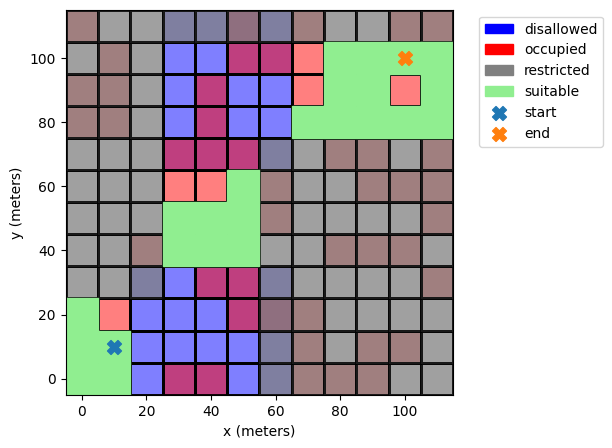

In [78]:
fig, ax = ha.flows['environment'].c.show(properties=properties, collections=collections, xlabel="x (meters)", ylabel="y (meters)")
ax.scatter([10], [10], label="start", s=100, marker="X")
ax.scatter([100], [100], label="end", s=100, marker="X")
#xs = [x[0] for x in ha.p.flightplan]
#ys = [x[1] for x in ha.p.flightplan]
#ax.plot(xs, ys, label="flightplan", color="purple")
consolidate_legend(ax, title="properties")
fig.savefig("outputs_demo_contingency/environment.pdf",  bbox_inches='tight')
fig.savefig("outputs_demo_contingency/environment.svg",  bbox_inches='tight')

## Simulation

No intrusion....

In [79]:
ha = ContingencyAircraftArchitecture(p = {'intruders': ''})
res, hist = propagate.nominal(ha)

res

tend.classify.faultmodes:          set()
tend.classify.unsuitable_landing:  False
tend.classify.disallowed_landing:  False
tend.classify.occupied_landing:    False
tend.classify.restricted_landing:  False
tend.classify.restricted_flight:   False
tend.classify.mission_complete:     True
tend.classify.landing_damage:      False
tend.classify.crash:               False

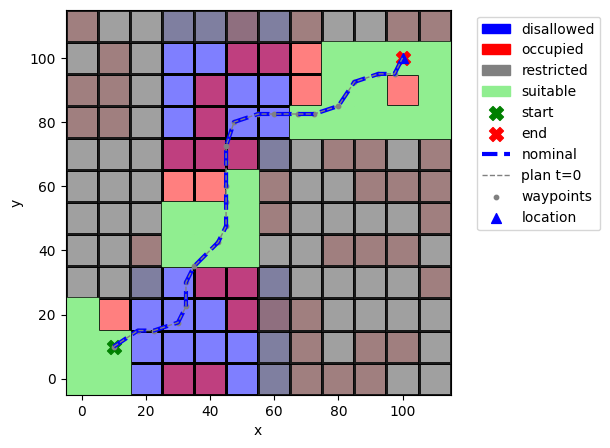

In [80]:
fig, ax = plot_flightpath(mdl=ha, history=hist)
# fig, ax = plot_flightpath(mdl=ha, history=hist, fig=fig, ax=ax)

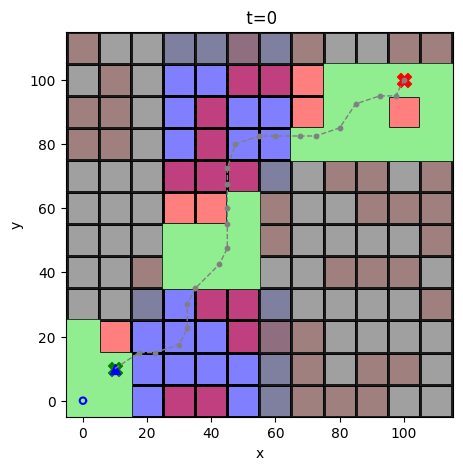

In [81]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False)
# HTML(ani.to_jshtml())

In [82]:
ani.save("outputs_demo_contingency/nominal_flightpath.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


MovieWriter ffmpeg unavailable; using Pillow instead.


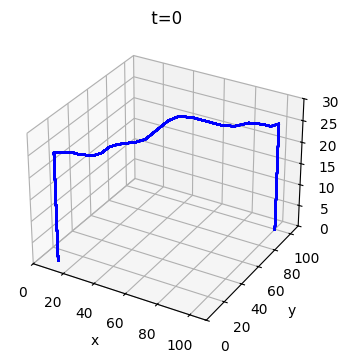

In [83]:

plot_values = ('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')
ani = hist.animate("plot_trajectories_from", z=True, plot_values=plot_values, legend=False,
                   color="blue", xlim = (0, 110), ylim=(0,110), zlim=(0,30))
ani.save("outputs_demo_contingency/nominal_flightpath3d.gif")

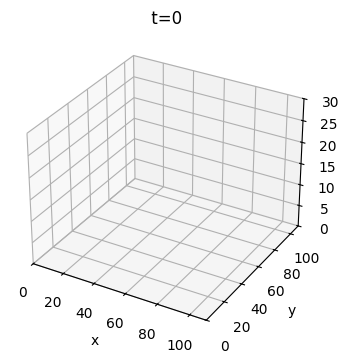

In [84]:
ani = hist.animate("plot_trajectories_from", z=True, plot_values=plot_values, legend=False,
                   color="blue", xlim = (0, 110), ylim=(0,110), zlim=(0,30))
# HTML(ani.to_jshtml())

With intrusion...

In [85]:
ha = ContingencyAircraftArchitecture(p = {'intruders': 'across', 'with_proxthreat': False})
res, hist = propagate.nominal(ha)

res

C:\Users\dhulse\Documents\GitHub\fmdtools\src\fmdtools\sim\propagate.py:688: UserWarning: Faults found during the nominal run {'control_flight.loss': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim'), 'aviate.crash': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim'), 'store_and_supply_ee.break': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim'), 'perceive_environment.break': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim'), 'hold_payload.break': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim')}
  warnings.warn("Faults found during the nominal run " + str(endfaults))


tend.classify.faultmodes: {'control_flight.loss', 'hold_payload.break', 'perceive_environment.break', 'aviate.crash', 'store_and_supply_ee.break'}
tend.classify.unsuitable_landing:   True
tend.classify.disallowed_landing:  False
tend.classify.occupied_landing:     True
tend.classify.restricted_landing:  False
tend.classify.restricted_flight:   False
tend.classify.mission_complete:    False
tend.classify.landing_damage:       True
tend.classify.crash:                True

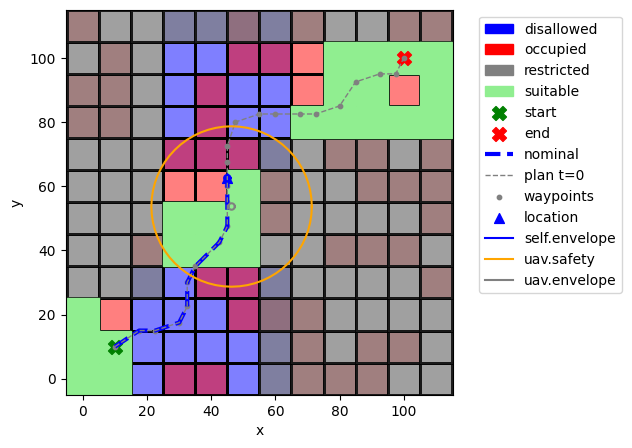

In [86]:
fig, ax = plot_flightpath(mdl=ha, history=hist, with_plans=True, boundaries_at=30)

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

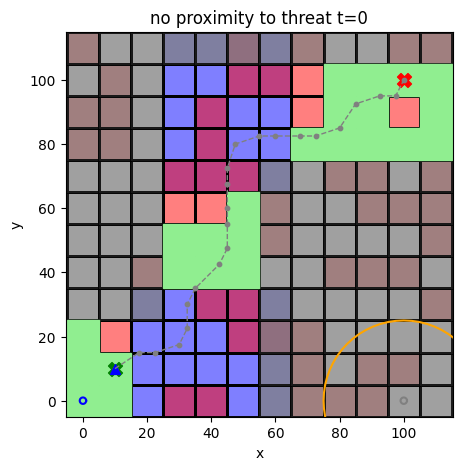

In [87]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False,
                   xlim=(-5, 115), ylim=(-5,115), title="no proximity to threat")
# HTML(ani.to_jshtml())
ani.save("outputs_demo_contingency/intrusion_without_proxthreat.gif")

In [88]:
ha = ContingencyAircraftArchitecture(p = {'intruders': 'across', 'with_proxthreat': True})
res, hist = propagate.nominal(ha)

In [89]:
hist.flows.trajectories.des_traj.s.goal_x
hist.fxns.control_flight.s.flightplan[30]

((np.float64(32.5), np.float64(30.0)),
 (np.float64(35.0), np.float64(35.0)),
 (np.float64(40.0), np.float64(42.5)),
 (np.float64(40.0), np.float64(47.5)),
 (np.float64(42.5), np.float64(55.0)),
 (np.float64(45.0), np.float64(60.0)),
 (np.float64(45.0), np.float64(67.5)),
 (np.float64(45.0), np.float64(72.5)),
 (np.float64(47.5), np.float64(80.0)),
 (np.float64(55.0), np.float64(82.5)),
 (np.float64(60.0), np.float64(82.5)),
 (np.float64(67.5), np.float64(82.5)),
 (np.float64(72.5), np.float64(82.5)),
 (np.float64(80.0), np.float64(85.0)),
 (np.float64(85.0), np.float64(92.5)),
 (np.float64(92.5), np.float64(95.0)),
 (np.float64(97.5), np.float64(95.0)),
 (np.float64(100.0), np.float64(100.0)))

(<Figure size 600x600 with 6 Axes>,
 array([<Axes: title={'center': 'flows.trajectories.s.x'}, xlabel=' '>,
        <Axes: title={'center': 'flows.trajectories.s.y'}, xlabel=' '>,
        <Axes: title={'center': 'flows.trajectories.s.z'}, xlabel=' '>,
        <Axes: title={'center': 'fxns.control_flight.m.mode'}, xlabel='time'>,
        <Axes: title={'center': 'flows.electricity.s.charge'}, xlabel='time'>,
        <Axes: >], dtype=object))

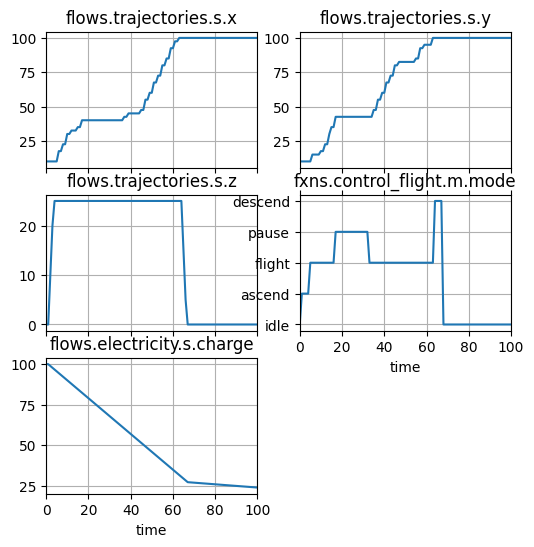

In [90]:
hist.plot_line('flows.trajectories.s.x', 'flows.trajectories.s.y','flows.trajectories.s.z', 'fxns.control_flight.m.mode', 'flows.electricity.s.charge')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


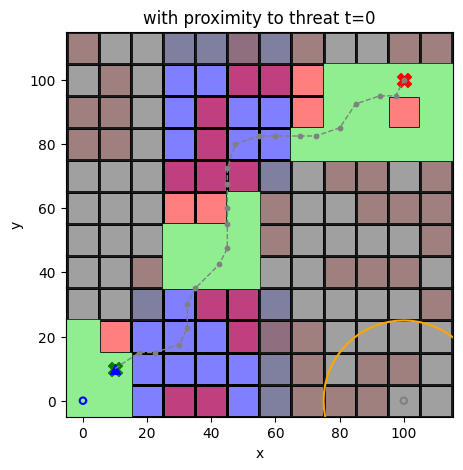

In [91]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False,
                   xlim=(-5, 115), ylim=(-5,115), title="with proximity to threat")
# HTML(ani.to_jshtml())

In [92]:
ani.save("outputs_demo_contingency/intrusion_with_proxthreat.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

Other intruders

In [93]:
ha = ContingencyAircraftArchitecture(p = {'intruders': 'middle', 'with_proxthreat': True})
res, hist = propagate.nominal(ha)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


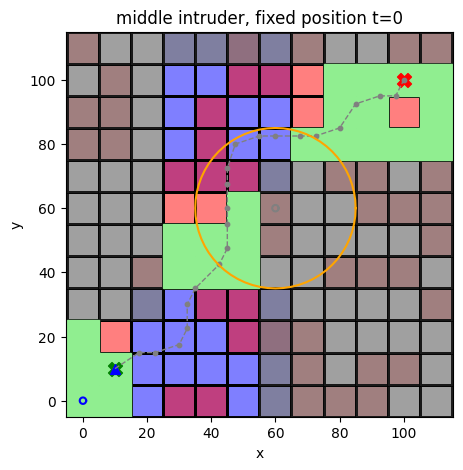

In [94]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False,
                   xlim=(-5, 115), ylim=(-5,115), title="middle intruder, fixed position")
# HTML(ani.to_jshtml())

In [95]:
ani.save("outputs_demo_contingency/intrusion_middle.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

Intruder Down

In [96]:
ha = ContingencyAircraftArchitecture(p = {'intruders': 'down', 'with_proxthreat': True})
res, hist = propagate.nominal(ha)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


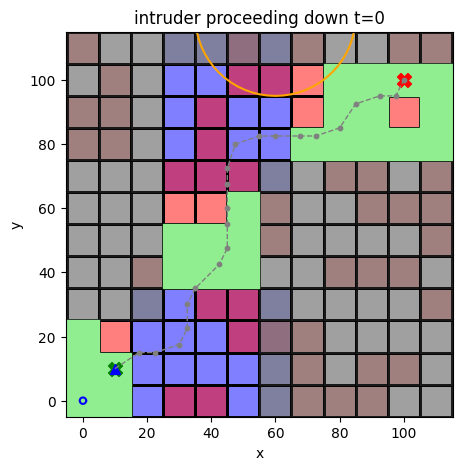

In [97]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False,
                   xlim=(-5, 115), ylim=(-5,115), title="intruder proceeding down")
# HTML(ani.to_jshtml())

In [98]:
ani.save("outputs_demo_contingency/intrusion_middle_down.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

Entire feasible area covered

In [99]:
ha = ContingencyAircraftArchitecture(p = {'intruders': 'down-over', 'with_proxthreat': True})
res, hist = propagate.nominal(ha)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


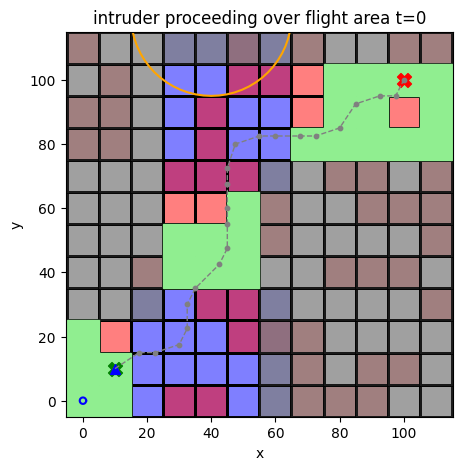

In [100]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False,
                   xlim=(-5, 115), ylim=(-5,115), title="intruder proceeding over flight area")
# HTML(ani.to_jshtml())

In [101]:
ani.save("outputs_demo_contingency/intrusion_middle_down_over.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

## Fault Scenarios

### Loss of Control

In [102]:
ha = ContingencyAircraftArchitecture(p = {'intruders': '', 'with_proxthreat': True})
res, hist = propagate.one_fault(ha, 'control_flight', 'loss', 9, to_return=['classify', 'graph'])
res

nominal.tend.classify.faultmodes:  set()
nominal.tend.classif               False
nominal.tend.classif               False
nominal.tend.classify.occupied_landing: False
nominal.tend.classif               False
nominal.tend.classif               False
nominal.tend.classify.mission_complete: True
nominal.tend.classify.landing_damage: False
nominal.tend.classify.crash:       False
nominal.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001CFE86C5D00>
control_flight_loss_{'control_flight.loss', 'hold_payload.break', 'perceive_environment.break', 'aviate.crash', 'store_and_supply_ee.break'}
control_flight_loss_                True
control_flight_loss_                True
control_flight_loss_               False
control_flight_loss_               False
control_flight_loss_               False
control_flight_loss_               False
control_flight_loss_                True
control_flight_loss_                True
control_flight_loss_t9.tend.graph: 

In [103]:
graph = res.faulty.tend.graph

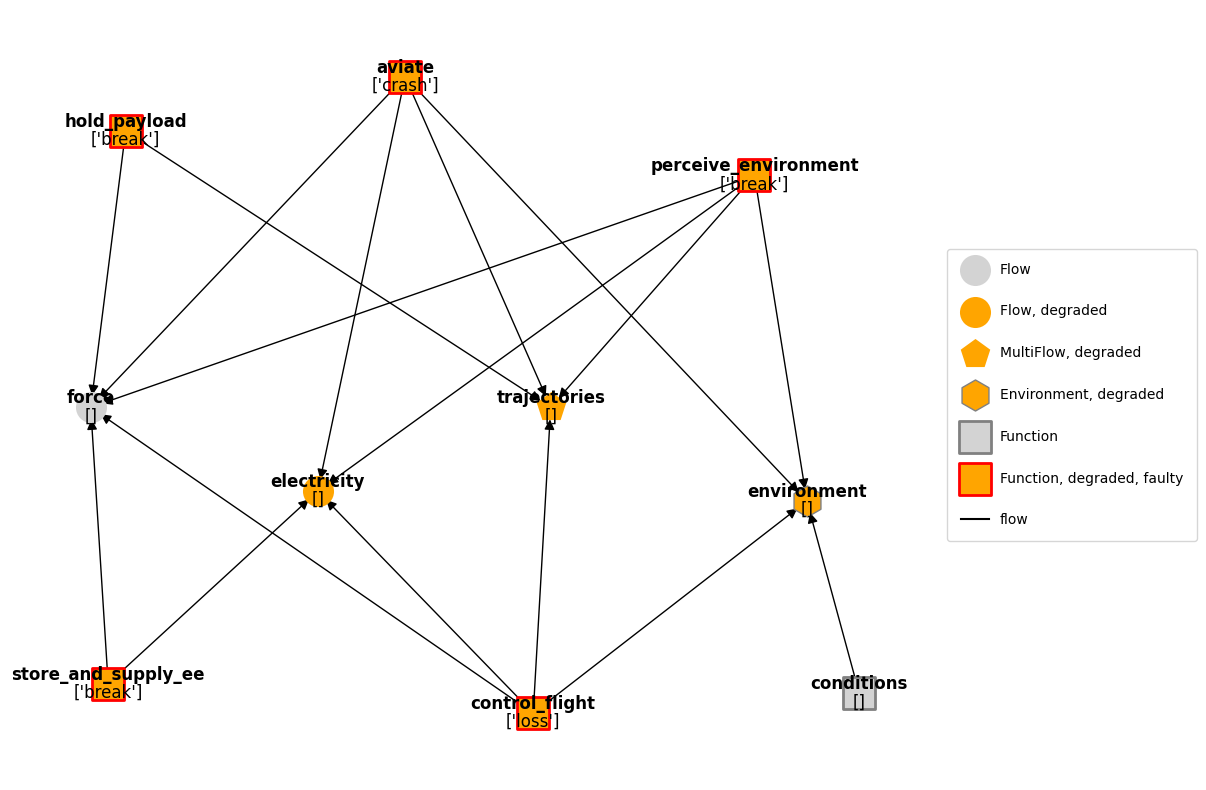

In [104]:
graph.set_pos(**pos)
graph.set_node_labels(title='shortname', subtext='faults_and_indicators')
graph.set_edge_labels(title='')
graph.draw()
fig.savefig('outputs_demo_contingency/arch_no_con.pdf')

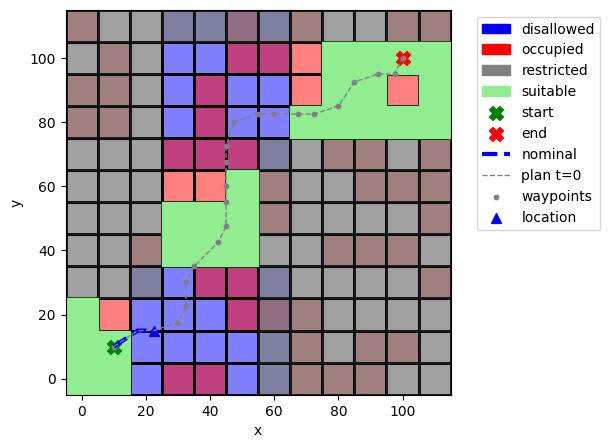

In [105]:
fig, ax = plot_flightpath(ha, hist.faulty)
fig.savefig('outputs_demo_contingency/traj_no_con.pdf')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

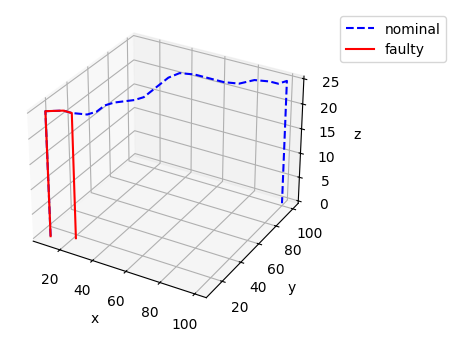

In [106]:
hist.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

### Battery Depletion

In [107]:
ha = ContingencyAircraftArchitecture(p={'depletion': 35.0, 'intruders': ''})
res, hist = propagate.one_fault(ha, 'store_and_supply_ee', 'depletion', 20, to_return=['classify', 'graph'])

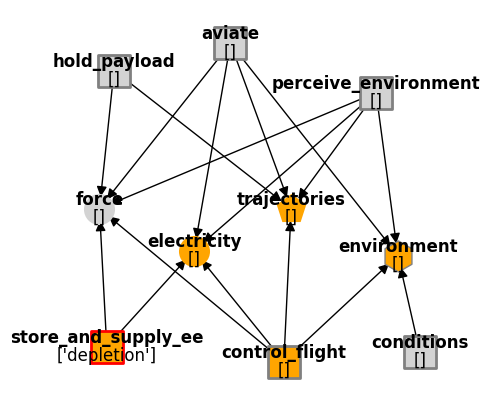

In [108]:
graph = res.faulty.tend.graph
graph.set_pos(**pos)
graph.set_node_labels(title='shortname', subtext='faults_and_indicators')
graph.set_edge_labels(title='')
fig, ax =graph.draw(figsize=(5,5), withlegend=False)
fig.savefig('outputs_demo_contingency/arch_bat_depletion.pdf',  bbox_inches='tight')

In [109]:
hist.faulty.fxns.control_flight.s.flightplan[29]

((np.float64(45.0), np.float64(72.5)),
 (np.float64(45.0), np.float64(70.0)),
 (np.float64(45.0), np.float64(57.5)),
 (np.float64(50.0), np.float64(60.0)))

In [110]:
hist.faulty.flows.trajectories.perc_traj.s.x[30]

np.float64(45.0)

In [111]:
hist.faulty.flows.electricity.s.charge[30]

np.float64(22.899999999999984)

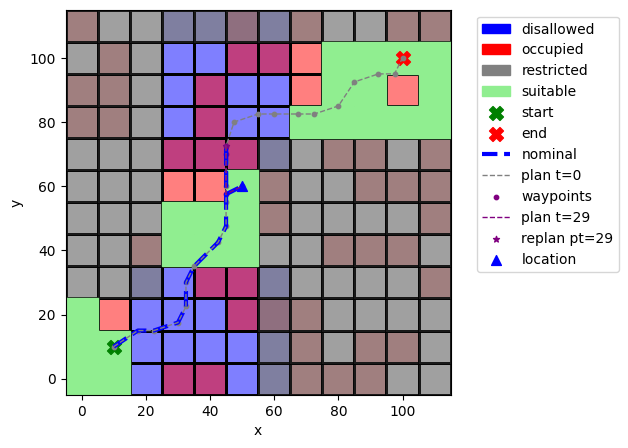

In [112]:
fig, ax = plot_flightpath(ha, hist.faulty)
fig.savefig('outputs_demo_contingency/traj_bat_depletion.pdf')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


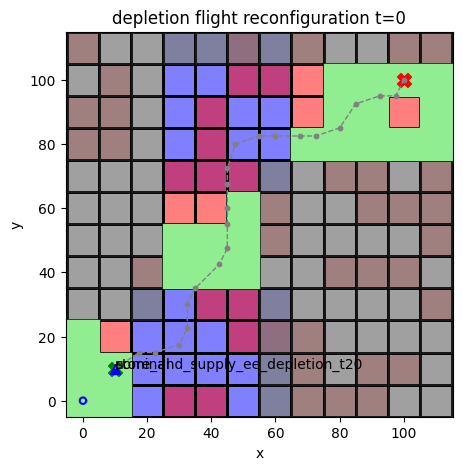

In [113]:
ani = hist.animate(plot_flightpath_from, mdl=ha, figsize=(5,5), legend_kwargs=False, text=True,
                   xlim=(-5, 115), ylim=(-5,115), title="depletion flight reconfiguration")
# HTML(ani.to_jshtml())

In [114]:
ani.save("outputs_demo_contingency/depletion_t20.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

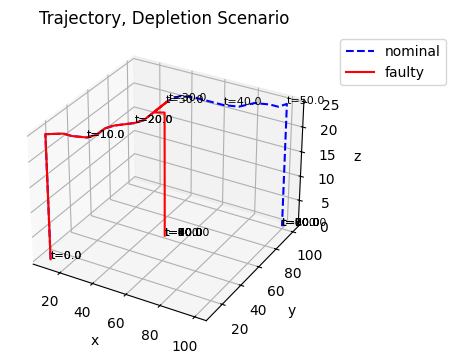

In [115]:
fig, ax = hist.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z',
                                 time_groups=['nominal', 'faulty'],
                                 mark_time=True, time_ticks=10,
                                 title="Trajectory, Depletion Scenario")
fig.savefig("outputs_demo_contingency/depletion_t20_traj.svg", bbox_inches='tight')

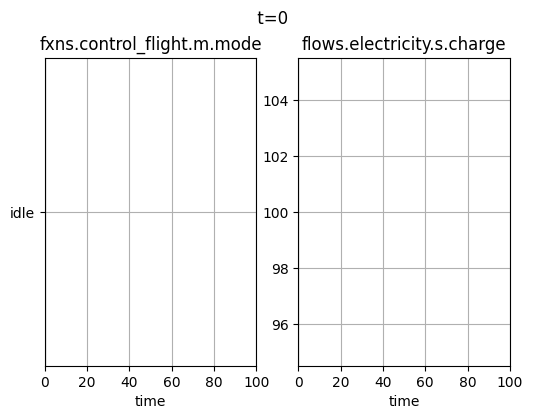

In [116]:
ani = hist.animate("plot_line_from",
                   plot_values=('fxns.control_flight.m.mode', 'flows.electricity.s.charge'),
                   legend_loc=False, t_line=True)
# HTML(ani.to_jshtml())

In [117]:
ani.save("outputs_demo_contingency/depletion_t20_line.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


<Figure size 640x480 with 0 Axes>

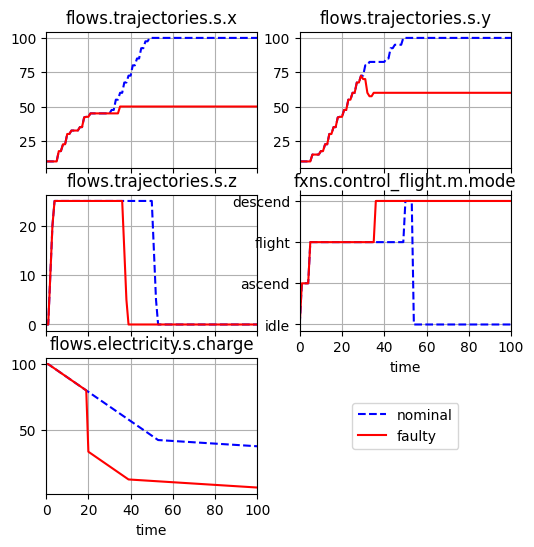

In [118]:
fig, ax = hist.plot_line('flows.trajectories.s.x', 'flows.trajectories.s.y','flows.trajectories.s.z', 'fxns.control_flight.m.mode', 'flows.electricity.s.charge')

## Statistical Simulation


Standard/25% depletion:

In [119]:
ha_base = ContingencyAircraftArchitecture(p={'intruders': ''})
res, hist = propagate.nominal(ha_base)
pms = from_hist(hist)
pm = pms['store_and_supply_ee']

In [120]:


ha_25 = ContingencyAircraftArchitecture(p={'depletion': 25.0, 'intruders': ''})
fd = FaultDomain(ha_25)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', args=(10,))
# fs.add_fault_phases('in_use', method='all')
fs

FaultSample of scenarios: 
 - store_and_supply_ee_depletion_t7p0
 - store_and_supply_ee_depletion_t11p0
 - store_and_supply_ee_depletion_t16p0
 - store_and_supply_ee_depletion_t21p0
 - store_and_supply_ee_depletion_t25p0
 - store_and_supply_ee_depletion_t30p0
 - store_and_supply_ee_depletion_t34p0
 - store_and_supply_ee_depletion_t39p0
 - store_and_supply_ee_depletion_t44p0
 - store_and_supply_ee_depletion_t48p0

In [121]:
res_25, hist_25 = propagate.fault_sample(ha_25, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:21<00:00,  2.13s/it]


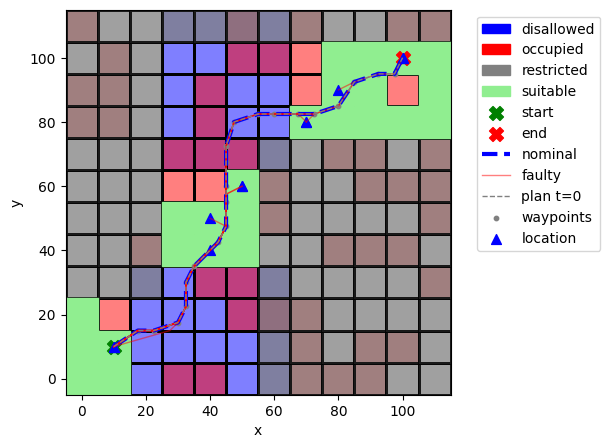

In [122]:
fig, ax = plot_flightpath(ha_25, hist_25)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


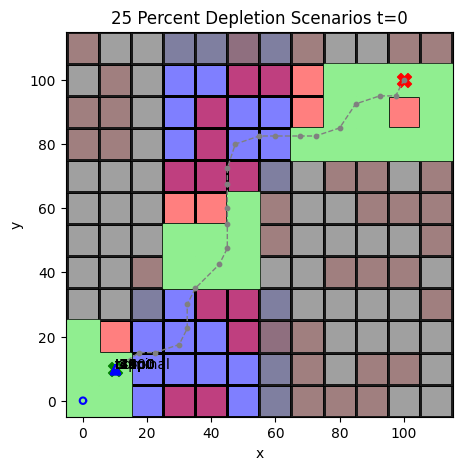

In [123]:
ani = hist_25.animate(plot_flightpath_from, mdl=ha_25, figsize=(5,5), legend_kwargs=False, text="split",
                   xlim=(-5, 115), ylim=(-5,115), title="25 Percent Depletion Scenarios")
# HTML(ani.to_jshtml())

In [124]:
ani.save("outputs_demo_contingency/depletion_25p_scens.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

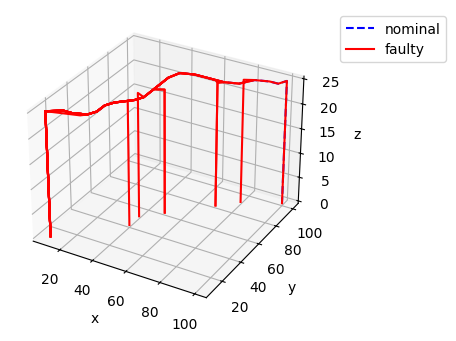

In [125]:
hist_25.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

18% depletion

In [126]:
ha_20 = ContingencyAircraftArchitecture(p={'depletion': 18.0, 'intruders': ''})
fd = FaultDomain(ha_20)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', args=(10,))
fs
res_20, hist_20 = propagate.fault_sample(ha_20, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:22<00:00,  2.21s/it]


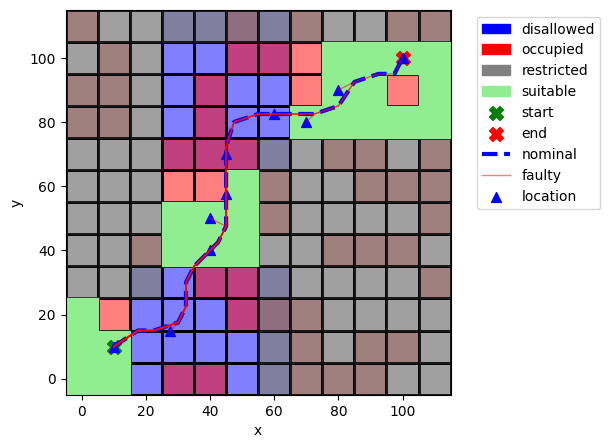

In [127]:
fig, ax = plot_flightpath(ha_20, hist_20, with_plans=False)
fig.savefig('outputs_demo_contingency/depletion_flightpath18.pdf',  bbox_inches='tight')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


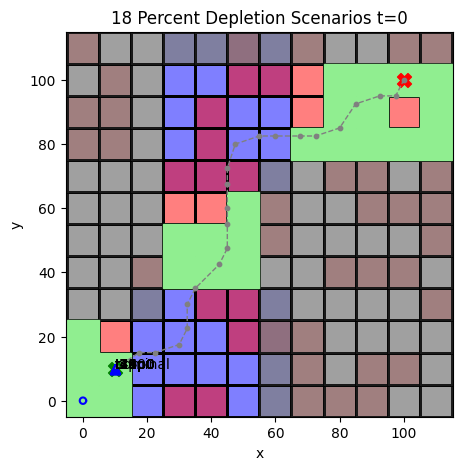

In [128]:
ani = hist_20.animate(plot_flightpath_from, mdl=ha_20, figsize=(5,5), legend_kwargs=False, text="split",
                   xlim=(-5, 115), ylim=(-5,115), title="18 Percent Depletion Scenarios")
# HTML(ani.to_jshtml())

In [129]:
ani.save("outputs_demo_contingency/depletion_18p_scens.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

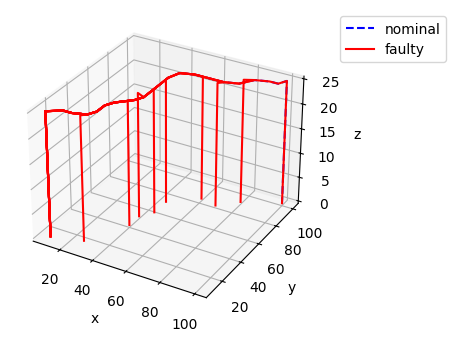

In [130]:
hist_20.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

0% depletion

In [131]:
ha_0 = ContingencyAircraftArchitecture(p={'depletion': 0.0, 'intruders': ''})
fd = FaultDomain(ha_0)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use',  args=(10,))
fs
res_0, hist_0 = propagate.fault_sample(ha_0, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:02<00:00,  4.19it/s]


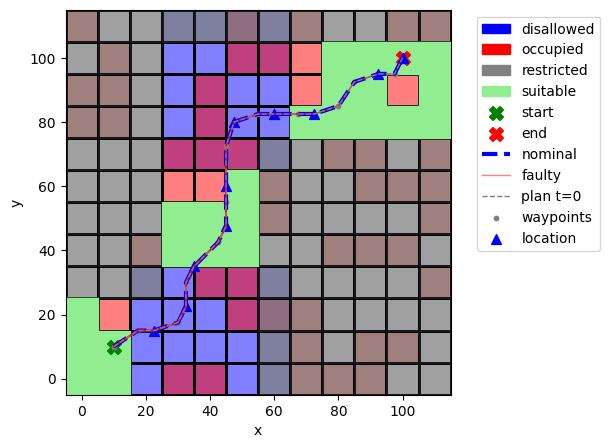

In [132]:
fig, ax = plot_flightpath(ha_0, hist_0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


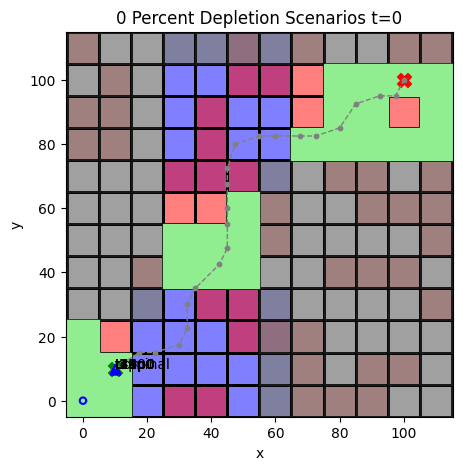

In [133]:
ani = hist_0.animate(plot_flightpath_from, mdl=ha_20, figsize=(5,5), legend_kwargs=False, text="split",
                   xlim=(-5, 115), ylim=(-5,115), title="0 Percent Depletion Scenarios")
# HTML(ani.to_jshtml())

In [134]:
ani.save("outputs_demo_contingency/depletion_0p_scens.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

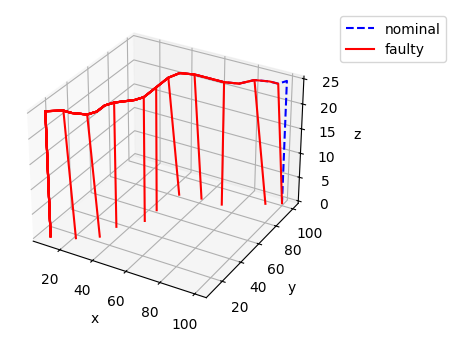

In [135]:
hist_0.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

In [136]:
fm = FMEA(res_0, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm0 = fm.as_table()
fm0 = fm0.rename(index={'store_and_supply_ee': ''})
fm0 = fm0.rename(index={'depletion': 'depletion (0%)'})
fm0

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (0%),0.1,0.9,0.4,0.1,1.0,1.0


In [137]:
fm = FMEA(res_20, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm20 = fm.as_table()
fm20 = fm20.rename(index={'store_and_supply_ee': ''})
fm20 = fm20.rename(index={'depletion': 'depletion (18%)'})
fm20

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (18%),0.1,0.4,0.3,0.2,0.0,0.0


In [138]:
fm = FMEA(res_25, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm25 = fm.as_table()
fm25 = fm25.rename(index={'store_and_supply_ee': ''})
fm25 = fm25.rename(index={'depletion': 'depletion (25%)'})
fm25

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (25%),0.1,0.0,0.0,0.0,0.0,0.0


In [139]:
import pandas as pd
full_fm = pd.concat([fm0, fm20, fm25])
full_fm = full_fm*100
full_fm = full_fm.rename(columns = {'percent_mission_complete': 'mission complete',
                                    'percent_unsuitable_landing': 'unsuitable site',
                                    'percent_disallowed_landing': 'disallowed site',
                                    'percent_occupied_landing': 'occupied site',
                                    'percent_landing_damage': 'damaged',
                                    'percent_crash': 'crashed'})
full_fm = full_fm.style.format(precision=1)
full_fm

In [140]:
print(full_fm.to_latex())

\begin{tabular}{llrrrrrr}
 &  & mission complete & unsuitable site & disallowed site & occupied site & damaged & crashed \\
\multirow[c]{3}{*}{} & depletion (0%) & 10.0 & 90.0 & 40.0 & 10.0 & 100.0 & 100.0 \\
 & depletion (18%) & 10.0 & 40.0 & 30.0 & 20.0 & 0.0 & 0.0 \\
 & depletion (25%) & 10.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
\end{tabular}



In [141]:
# print(full_fm.data.to_markdown())

## Different Mission

In [142]:
from fmdtools.analyze.phases import from_hist
ha_base = ContingencyAircraftArchitecture(p={'intruders': '', 'gridcase': 'all_disallowed'})
res, hist = propagate.nominal(ha_base)
pms = from_hist(hist)
pm = pms['store_and_supply_ee']

In [143]:
from fmdtools.sim.sample import FaultDomain, FaultSample

ha_25 = ContingencyAircraftArchitecture(p={'depletion': 25.0, 'intruders': '', 'gridcase': 'all_disallowed'})
fd = FaultDomain(ha_25)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', args=(10,))
# fs.add_fault_phases('in_use', method='all')
fs

FaultSample of scenarios: 
 - store_and_supply_ee_depletion_t7p0
 - store_and_supply_ee_depletion_t11p0
 - store_and_supply_ee_depletion_t16p0
 - store_and_supply_ee_depletion_t21p0
 - store_and_supply_ee_depletion_t26p0
 - store_and_supply_ee_depletion_t30p0
 - store_and_supply_ee_depletion_t35p0
 - store_and_supply_ee_depletion_t40p0
 - store_and_supply_ee_depletion_t45p0
 - store_and_supply_ee_depletion_t49p0

In [144]:
res_25, hist_25 = propagate.fault_sample(ha_25, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:21<00:00,  2.17s/it]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


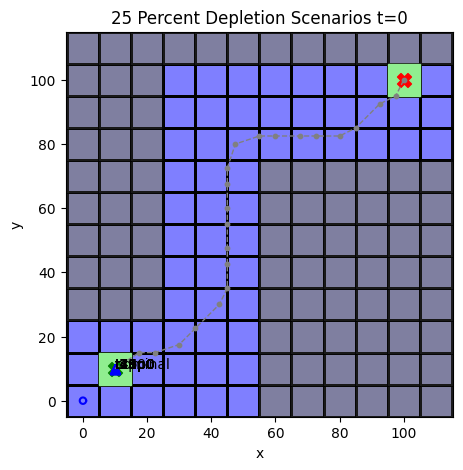

In [145]:
ani = hist_25.animate(plot_flightpath_from, mdl=ha_25, figsize=(5,5), legend_kwargs=False, text="split",
                   xlim=(-5, 115), ylim=(-5,115), title="25 Percent Depletion Scenarios")
# HTML(ani.to_jshtml())

In [146]:
ani.save("outputs_demo_contingency/25p_scens_all_disallowed.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed dat

In [147]:
fm = FMEA(res_25, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'landing_damage', 'crash'])
fm25 = fm.as_table()
fm25 = fm25.rename(index={'store_and_supply_ee': ''})
fm25 = fm25.rename(index={'depletion': 'depletion (25%)'})
fm25

,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_landing_damage,percent_crash
,depletion (25%),0.2,0.5,0.4,0.0,0.0
